# Deep Learning Volatility: Rough Bergomi Calibration

This notebook reproduces the rough Bergomi experiments of *Deep Learning Volatility* by
Horvath, Muguruza & Tomas ([arXiv:1901.09647](https://arxiv.org/abs/1901.09647)), for the
course **MA435 Machine Learning in Financial Mathematics**. The accompanying report discusses the theory and mathematical formulation more thoroughly; while here we focus on the implementation.

**Main contents:**

1. **Dataset generation**: a Monte Carlo pricer for the rough Bergomi model, used to build
   (parameters, price surface) training pairs, together with the Monte Carlo
   *error floor* that sets the accuracy target.
2. **Approximation network**: a small neural network trained to approximate the pricing map
   $\widetilde F:\theta\mapsto$ surface, for each derivative type: vanilla call option and digital barrier option
3. **Calibration**: recovering parameters from a surface in milliseconds by least-squares
   optimisation over the frozen network.

## Introduction

**Calibration** is the inverse problem of choosing model parameters $\theta$ so that the model
reproduces observed market prices. Formally, given a pricing map $P:\theta\mapsto$ prices and
market data $P^{\mathrm{MKT}}$, we seek

$$\hat\theta = \arg\min_{\theta}\;\big\lVert P(\theta) - P^{\mathrm{MKT}}\big\rVert^2 .$$

For **rough volatility** models this is very time consuming as each evaluation of $P(\theta)$ requires an expensive Monte Carlo simulation, and an optimiser calls $P$ hundreds of times when searching for $\hat\theta$. This pricing bottleneck is the obstacle the paper removes.

**The two-step idea.** Split the work into an expensive offline stage and a cheap online stage:

- **(i) Learn Approximate Pricing Function (offline):**
  - Train a neural network $\widetilde F$ to approximate the pricing map
  $P : \theta\mapsto$ price surface (a fixed grid of derivative prices) using Monte Carlo prices as training labels. The grid is:
    - strike × maturity for vanilla options, and
    - barrier level × maturity for digital barriers.
- **(ii) Calibrate (online):**
  - Using the approximated pricing function, solve
  $\hat\theta=\arg\min_\theta\lVert\widetilde F(\theta)-\sigma^{\mathrm{MKT}}\rVert^2$. Since
  $\widetilde F$ is now cheap, deterministic and differentiable, this runs in milliseconds.

**Scope.** We focus on the rough Bergomi model with a flat forward-variance level, so
$\theta=(\xi_0,\nu,\rho,H)$ has four parameters, but the method applies to any model of the underlying.

## Setup

- Imports and global configuration
- We set Keras and JAX to use double precision to get within the Monte Carlo error floor

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"     # run Keras 3 on the JAX backend (Keras on pytorch has a bug on double precision)

import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import keras
keras.backend.set_floatx("float64")      # using double precision to get within Monte Carlo error floor

from scipy.optimize import least_squares
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng_seed = 42
keras.utils.set_random_seed(rng_seed)    # seed python / numpy / backend together
print("keras", keras.__version__, "| backend:", keras.backend.backend())

keras 3.14.1 | backend: jax


## 1. Dataset generation

To train the approximation network we need many *(parameter, price surface)* pairs as training data. To this end, we sample parameters, price a whole option grid by Monte Carlo, and store the
result as a flat "image".

### 1.1 Samples and their pricing

A single sample maps one parameter vector $\theta=(\xi_0,\nu,\rho,H)$ to a **price surface on a fixed grid** which can be viewed as an image the network learns to reproduce. The parameters are the *features*
and the surface is the *label*. We build this for two products:

- **Vanilla calls**
  - 11 strikes (0.5–1.5) × 8 maturities (0.1–2.0 years) = 88 points
  - Strikes are equivalent to moneyness, since $S_0=1$
  - We invert each Monte Carlo call price to its **Black–Scholes implied volatility** which plays the role of the "price" of the options
  - Working in implied volatility strips out most of the strike / maturity scale and gives
    the network a better-conditioned target
  
- **Down-and-out digital barriers**
  - 11 barrier levels (0.45–0.95) × 8 maturities (0.1–2.0 years)
  - All barriers lie below spot $S_0=1$
  - The price is a probability in $[0,1]$, and we learn the price surface directly (errors
  reported in basis points rather than percent).

Under the risk-neutral measure ($r=0$) the **rough Bergomi** model (Bayer–Friz–Gatheral) is

$$dX_t=-\tfrac12 V_t\,dt+\sqrt{V_t}\,dW_t,\qquad
  V_t=\xi_0\exp\!\Big(\sqrt{2H}\,\nu\,Y_t-\tfrac12\nu^2 t^{2H}\Big),$$

where $X=\log S$, $Y$ is a Riemann–Liouville fractional Brownian motion with
$\mathrm{corr}(W,Z)=\rho$, and the Hurst exponent $H<\tfrac12$ sets the roughness. There is
no closed-form price, so both products are priced by Monte Carlo using the variance-reduced
rDonsker scheme of Horvath–Jacquier–Muguruza-Sojmark
([arXiv:1711.03078](https://arxiv.org/abs/1711.03078)). The simulation scheme and its
variance reduction are developed in the report; here we keep to a high-level view.

The option price grid and parameter ranges follow the paper (§4.1.1):

| Parameter | Symbol | Range | Meaning |
|-----------|--------|-------|---------|
| `xi0` | $\xi_0$ | $[0.01,\,0.16]$ | forward variance level |
| `nu`  | $\nu$   | $[0.30,\,4.00]$ | volatility-of-volatility |
| `rho` | $\rho$  | $[-0.95,\,-0.10]$ | spot–vol correlation (leverage effect) |
| `H`   | $H$     | $[0.025,\,0.50]$ | Hurst exponent — roughness; $H<\tfrac12$ is "rough" |


In [2]:
# Fixed grid and rough-Bergomi parameter ranges. theta = (xi0, nu, rho, H)
PARAM_NAMES = ["xi0", "nu", "rho", "H"]
PARAM_TEX   = [r"$\xi_0$", r"$\nu$", r"$\rho$", r"$H$"]
LB = np.array([0.01, 0.30, -0.95, 0.025])   # lower bounds
UB = np.array([0.16, 4.00, -0.10, 0.500])   # upper bounds

STRIKES    = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])           # 11
MATURITIES = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])                           # 8
BARRIERS   = np.array([0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]) # 11

N_STRIKE, N_MAT, N_BARRIER = len(STRIKES), len(MATURITIES), len(BARRIERS)
GRID_SIZE = N_MAT * N_STRIKE        # 88
print(f"surface grid = {N_MAT} maturities x {N_STRIKE} strikes = {GRID_SIZE} points")

# Report figure directory: report-bound figures are saved here (dpi=200, tight bbox) as they are drawn.
REPORT_DIR = "../report"

# Saved datasets (each row = [4 params | 88-point surface]); the SE files are (N, 88).
IV_PATH         = "../data/rBergomiDataset_MA435_iv.npy"
IV_SE_PATH      = "../data/rBergomiDataset_MA435_se_iv.npy"
DO_PATH         = "../data/rBergomiDataset_MA435_barrier_DO.npy"
DI_PATH         = "../data/rBergomiDataset_MA435_barrier_DI.npy"
BARRIER_SE_PATH = "../data/rBergomiDataset_MA435_barrier_se.npy"

GENERATE = False   # False -> load the generated dataset (the long MC run is already
                   # saved below). Set True to re-price from scratch (hours of MC).

# Set TRAIN to False to load cached weights and history
TRAIN = True
IV_WEIGHTS_PATH      = "../data/model_iv.weights.h5"
IV_HISTORY_PATH      = "../data/model_iv_history.npz"
BARRIER_WEIGHTS_PATH = "../data/model_barrier.weights.h5"
BARRIER_HISTORY_PATH = "../data/model_barrier_history.npz"

surface grid = 8 maturities x 11 strikes = 88 points


### 1.2 The pricers

Pricing one parameter vector $\theta$ is a single Monte Carlo pass: `variance_path` simulates the
rough Bergomi variance process, and `call_and_barrier_prices` turns those paths into both the
vanilla call grid and the digital-barrier grid. The Black–Scholes call that bridges prices and
implied volatilities is defined further down, alongside the implied-vol inversion that uses it.

`variance_path` simulates the variance process of the rough Bergomi model via the rDonsker / hybrid scheme.
It returns the variance process, the time grid, and the raw normal increments driving $W$, kept so the
correlated parallel leg can reuse them.

In [3]:
from functools import partial


@partial(jax.jit, static_argnums=(0, 1))
def variance_path(n, M, H, T, xi0, nu, key):
    dW_raw = jax.random.normal(key, (M, n - 1))
    dt_H = (1.0 / (n - 1)) ** H
    i = jnp.arange(1, n, dtype=jnp.float64)
    kernel = ((i ** (2 * H) - (i - 1.0) ** (2 * H)) / (2.0 * H)) ** 0.5
    conv = jax.vmap(lambda row: jnp.convolve(kernel, dt_H * row))(dW_raw)[:, : n - 1]
    Y = jnp.concatenate([jnp.zeros((M, 1)), conv], axis=1) * T ** H

    times = jnp.linspace(0.0, T, n)
    V = xi0 * jnp.exp(jnp.sqrt(2 * H) * nu * Y - 0.5 * nu ** 2 * times[None, :] ** (2 * H))
    return V, times, dW_raw

`call_and_barrier_prices` given a parameter vector $\theta$ performs one Monte Carlo pass, pricing both vanilla and barrier grids from the same simulated paths.

* **Variance and parallel leg.** We simulate the variance process $V$ (`variance_path`) and the parallel log-price component $X^{\parallel}$, driven by the Brownian motion $W$ correlated with the volatility.
* **Vanilla pricing.** Conditional on the variance path and $X^{\parallel}$, the remaining perpendicular randomness is independent Gaussian, so each call price reduces to a Black–Scholes formula in the realised forward and integrated variance. Averaging these closed-form values rather than raw payoffs gives a significant variance reduction, as applied in Horvath–Jacquier–Muguruza (Alg. 3.6). A multiplicative control variate enforcing $\mathbb{E}[S_T]=1$ reduces the variance further.
* **Barrier pricing.** We additionally simulate the perpendicular leg $X^{\perp}$ to form the full log-price $X = X^{\parallel}+X^{\perp}$, and correct for discrete monitoring via the Brownian-bridge survival probability between consecutive steps (Glasserman, 2004).

Both surfaces are returned with their Monte Carlo standard errors. Full derivations are given in the report.


In [4]:
@partial(jax.jit, static_argnums=(0, 1))
def call_and_barrier_prices(n, M, H, T, xi0, nu, rho, key, strikes, maturities, barriers):
    """
    MC pass -> (call_prices, call_se, DO_prices, DO_se).
    """
    dt = T / (n - 1)
    k_var, k_perp = jax.random.split(key)
    V, _t, dW_raw = variance_path(n, M, H, T, xi0, nu, k_var)
    sqrtV = jnp.sqrt(jnp.maximum(V, 0.0))

    # X_par: the W-driven half of log-spot, dX_par = -1/2 rho^2 V dt + rho sqrt(V) dW
    incr_par = -0.5 * rho ** 2 * V[:, :-1] * dt + rho * sqrtV[:, :-1] * (jnp.sqrt(dt) * dW_raw)
    X_par = jnp.concatenate([jnp.zeros((M, 1)), jnp.cumsum(incr_par, axis=1)], axis=1)

    idx = jnp.round(maturities / dt).astype(jnp.int32)              # maturity -> grid index
    Sigma = (1.0 - rho ** 2) * dt * jnp.concatenate(               # conditional variance
        [jnp.zeros((M, 1)), jnp.cumsum(V[:, :-1], axis=1)], axis=1)

    # ---- vanilla: each path -> BS price with (F, Sigma); the CV enforces E[S_T] = 1 ----
    F = jnp.exp(X_par[:, idx])
    F = F / F.mean(axis=0, keepdims=True)
    S2 = Sigma[:, idx]
    F_, S2_, K_ = F[:, :, None], S2[:, :, None], strikes[None, None, :]
    sq = jnp.sqrt(S2_)
    d1 = (jnp.log(F_ / K_) + 0.5 * S2_) / sq
    call_path = F_ * jax.scipy.stats.norm.cdf(d1) - K_ * jax.scipy.stats.norm.cdf(d1 - sq)
    call_prices = call_path.mean(axis=0)
    call_se = call_path.std(axis=0) / jnp.sqrt(M)

    # ---- barrier: add the W_perp leg, then the bridge-survival probability ----
    dW_perp = jax.random.normal(k_perp, (M, n - 1))
    bar = jnp.sqrt(1.0 - rho ** 2)
    incr_perp = -0.5 * (1.0 - rho ** 2) * V[:, :-1] * dt + bar * sqrtV[:, :-1] * (jnp.sqrt(dt) * dW_perp)
    log_S = X_par + jnp.concatenate([jnp.zeros((M, 1)), jnp.cumsum(incr_perp, axis=1)], axis=1)

    log_B = jnp.log(barriers)[None, None, :]
    gap_l = jnp.maximum(log_S[:, :-1, None] - log_B, 0.0)
    gap_r = jnp.maximum(log_S[:, 1:, None] - log_B, 0.0)
    bridge = 1.0 - jnp.exp(-2.0 * gap_l * gap_r / jnp.maximum(V[:, :-1, None] * dt, 1e-30))
    p_no_hit = jnp.where((gap_l > 0) & (gap_r > 0), bridge, 0.0)
    surv = jnp.concatenate([jnp.ones((M, 1, N_BARRIER)), jnp.cumprod(p_no_hit, axis=1)], axis=1)
    DO = surv[:, idx, :]
    return call_prices, call_se, DO.mean(axis=0), DO.std(axis=0) / jnp.sqrt(M)

With the Monte Carlo prices in hand, we convert the vanilla calls to implied volatilities, which we
use as the target for the neural network. The Black–Scholes call is the bridge: `bs_call_jax` is a
vectorised version ($S_0=1$, $r=0$) that broadcasts over strike, maturity and volatility, and it is
the forward map the implied-vol inverter bisects. It runs on-device so that whole price grids invert
in one pass.

In [5]:
_NORM = jax.scipy.stats.norm


def bs_call_jax(K, T, sigma):
    """Vectorised Black-Scholes call (S0=1, r=0); broadcasts over K, T, sigma."""
    s = sigma * jnp.sqrt(T)
    d1 = (jnp.log(1.0 / K) + 0.5 * s * s) / s
    price = _NORM.cdf(d1) - K * _NORM.cdf(d1 - s)
    return jnp.where(s > 0, price, jnp.maximum(1.0 - K, 0.0))   # sigma->0 limit = intrinsic

`implied_vol_jax` recovers the implied volatility by bisecting `bs_call_jax` to find the root:

- returns $0$ where the option carries no time value,
- returns `NaN` where the price lies outside the no-arbitrage bounds.

`invert_prices_to_iv` applies this across a batch of surfaces and, in the same pass, attaches a
standard error in implied-volatility units by inverting both ends of the $95\%$ price interval.

In [6]:
# Batched Black-Scholes inversion.
_SIGMA_LO, _SIGMA_HI, _INTRINSIC_TOL, _N_BISECT = 1e-6, 5.0, 1e-10, 60


def implied_vol_jax(price, K, T):
    """Vectorised BS implied vol via bisection on bs_call_jax:
    sub-intrinsic -> NaN, zero time value -> 0.0, no bracket in [1e-6, 5] -> NaN."""
    price, K, T = jnp.broadcast_arrays(jnp.asarray(price, float),
                                       jnp.asarray(K, float), jnp.asarray(T, float))
    intrinsic = jnp.maximum(1.0 - K, 0.0)
    f_hi = bs_call_jax(K, T, _SIGMA_HI) - price                # > 0 iff a bracket exists

    def body(_, lh):
        lo, hi = lh
        mid = 0.5 * (lo + hi)
        fmid = bs_call_jax(K, T, mid) - price                  # increasing in sigma
        return jnp.where(fmid > 0.0, lo, mid), jnp.where(fmid > 0.0, mid, hi)

    lo, hi = jax.lax.fori_loop(0, _N_BISECT, body,
                               (jnp.full_like(price, _SIGMA_LO), jnp.full_like(price, _SIGMA_HI)))
    out = jnp.where(price <= intrinsic + _INTRINSIC_TOL, 0.0, 0.5 * (lo + hi))   # zero time value
    out = jnp.where(f_hi < 0.0, jnp.nan, out)                  # price above bracket -> NaN
    out = jnp.where(price < intrinsic - _INTRINSIC_TOL, jnp.nan, out)            # sub-intrinsic -> NaN
    return out


def invert_prices_to_iv(call_prices, call_se):
    """Invert a batch of MC call-price grids to flat (N, 88) IV + honest IV-SE surfaces.

    call_prices, call_se: (N, n_mat, n_strike). iv_se inverts both ends of the 95% price interval
    to vol space, iv_se = (sigma_hi - sigma_lo)/(2*1.96); NaN where an endpoint has no
    arbitrage-free inverse. Maturity-major, to match the rest of the notebook.
    """
    Kg, Tg = jnp.meshgrid(jnp.asarray(STRIKES), jnp.asarray(MATURITIES))   # (n_mat, n_strike)
    cp, cse = jnp.asarray(call_prices), jnp.asarray(call_se)
    half = 1.96 * cse
    iv = implied_vol_jax(cp, Kg, Tg)
    hi = implied_vol_jax(cp + half, Kg, Tg)
    lo = implied_vol_jax(jnp.maximum(cp - half, 0.0), Kg, Tg)
    iv_se = jnp.where(jnp.isfinite(hi) & jnp.isfinite(lo), (hi - lo) / (2.0 * 1.96), jnp.nan)
    N = cp.shape[0]
    return np.asarray(iv).reshape(N, -1), np.asarray(iv_se).reshape(N, -1)

### 1.3 Generate or load

Here we orchestrate the generation of the dataset by:
- Sampling parameter vectors $\theta$ from a uniform distribution over the parameter ranges.
- Batch-pricing the vanilla and barrier grids.
- Inverting the vanilla prices to obtain the implied-volatility surface.
- Saving the (parameter, price surface) pairs to disk.

In [7]:
N_STEPS, N_PATHS, BATCH = 201, 60_000, 5    # paper scale: 60k MC paths (§4.1.1); dt = T/(n-1) = 0.01
T_HORIZON = 2.0                              # = the longest maturity
# BATCH*N_PATHS is held ~constant vs the old 16*20_000, so peak memory is unchanged; raise BATCH if you have headroom.

# vmap the joint pricer across a batch of parameter sets (H, xi0, nu, rho, key vary; grids fixed)
_priced = jax.jit(jax.vmap(call_and_barrier_prices,
                           in_axes=(None, None, 0, None, 0, 0, 0, 0, None, None, None)),
                  static_argnums=(0, 1))


def generate_dataset(N, seed=0):
    """Sample N parameter sets, batch-price and invert; return params, iv, iv_se, do, di, do_se."""
    keys = jax.random.split(jax.random.PRNGKey(seed), N + 1)
    u = jax.random.uniform(keys[0], (N, 4))
    params = np.asarray(LB + u * (UB - LB))                       # uniform in each parameter range
    sj, mj, bj = jnp.asarray(STRIKES), jnp.asarray(MATURITIES), jnp.asarray(BARRIERS)

    iv = np.full((N, GRID_SIZE), np.nan); iv_se = np.full_like(iv, np.nan)
    do = np.empty((N, N_MAT * N_BARRIER)); do_se = np.empty_like(do)
    for s in range(0, N, BATCH):
        e = min(s + BATCH, N); p = jnp.asarray(params[s:e])
        cp, cse, dp, dse = _priced(N_STEPS, N_PATHS, p[:, 3], T_HORIZON, p[:, 0], p[:, 1], p[:, 2],
                                   keys[1 + s:1 + e], sj, mj, bj)
        iv[s:e], iv_se[s:e] = invert_prices_to_iv(cp, cse)       # vectorised on-device inversion
        do[s:e] = np.asarray(dp).reshape(e - s, -1); do_se[s:e] = np.asarray(dse).reshape(e - s, -1)
        print(f"  priced {e}/{N}")
    return params, iv, iv_se, do, 1.0 - do, do_se


def load_surface(path):
    """Load a saved [params | 88-surface] dataset -> (params (N,4), surface (N,88))."""
    arr = np.load(path, allow_pickle=True).astype(float)
    return arr[:, :4], arr[:, 4:]

We build the dataset (generating or loading), then drop any surface with a failed or degenerate
implied-vol inversion, so every retained implied vol is a genuine positive value and later
percentage errors stay finite. Barrier prices always invert, so the barrier set keeps all rows.

In [8]:
if GENERATE:
    params, iv, iv_se, do, di, do_se = generate_dataset(N=80_000, seed=0)  # paper: 68k train / 12k test at the 85/15 split
    bar_params = params
    # Persist the priced dataset in the same [params | surface] layout used on load, so a rerun
    # can set GENERATE = False and reload instead of repeating the (hours-long) Monte Carlo pass.
    np.save(IV_PATH, np.concatenate([params, iv], axis=1))
    np.save(IV_SE_PATH, iv_se)
    np.save(DO_PATH, np.concatenate([params, do], axis=1))
    np.save(DI_PATH, np.concatenate([params, di], axis=1))
    np.save(BARRIER_SE_PATH, do_se)
else:
    params, iv = load_surface(IV_PATH)
    iv_se = np.load(IV_SE_PATH, allow_pickle=True).astype(float)
    bar_params, do = load_surface(DO_PATH)
    _, di = load_surface(DI_PATH)
    do_se = np.load(BARRIER_SE_PATH, allow_pickle=True).astype(float)

# Drop surfaces with a failed/degenerate IV inversion (sigma <= 0 or non-finite) so every implied
# vol is a genuine value bounded away from zero and percentage errors stay finite.
valid = (iv > 0).all(axis=1) & np.isfinite(iv).all(axis=1)
params, iv, iv_se = params[valid], iv[valid], iv_se[valid]
print(f"IV dataset: kept {int(valid.sum())}/{len(valid)} surfaces "
      f"(dropped {int((~valid).sum())} with a failed/degenerate inversion)")
print("params:", params.shape, " iv:", iv.shape, " | barrier rows:", do.shape[0])

IV dataset: kept 61580/80000 surfaces (dropped 18420 with a failed/degenerate inversion)
params: (61580, 4)  iv: (61580, 88)  | barrier rows: 80000


### 1.4 The Monte Carlo error floor

Since the price surfaces are Monte Carlo estimates, they carry sampling noise. This noise sets an
error floor: the network cannot be more accurate than the data it learns from, and need only match
the floor, not beat it. We measure it as in the paper (§4.1, Figs 4–5): the relative half-width of
the $95\%$ Monte Carlo confidence interval on each price / implied volatility,

$$\text{floor}_{T,k}=\frac{1.96\,\mathrm{SE}_\sigma}{\sigma_{T,k}},$$

where $\mathrm{SE}_\sigma$ is the standard error in vol units built in §1.2. We report it across
the grid as Average and Std panels, in the same format as the network error in Section 2, so the
two are directly comparable.

Two plotting helpers used throughout: `plot_iv_surface` draws a single surface in 3D, and
`plot_error_panels` shows the Average and Std of a per-cell error across the grid

In [9]:
import warnings
from matplotlib.lines import Line2D


def plot_iv_surface(surface_88, ax=None, title=""):
    """3D plot of a flattened (88,) implied-vol surface over the (maturity, strike) grid."""
    Z = np.asarray(surface_88).reshape(N_MAT, N_STRIKE)
    Kg, Tg = np.meshgrid(STRIKES, MATURITIES)
    if ax is None:
        ax = plt.figure(figsize=(6, 4)).add_subplot(projection="3d")
    ax.plot_surface(Kg, Tg, Z, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_xlabel("strike $k$"); ax.set_ylabel("maturity $T$"); ax.set_zlabel(r"$\sigma_{BS}$")
    ax.set_title(title)
    return ax


def plot_error_panels(err_samples, title, xt, xlabel, scale=1.0, unit_label="%", save=None):
    """Average and Std of per-sample errors over the grid (cf. paper Figs 4, 6, 13).

    err_samples : (n_samples, N_MAT * len(xt)) per-cell errors; NaN entries are ignored, so a cell
    that is undefined for every sample is left blank.
    save : optional path; if given the figure is written there (dpi=200, tight bbox) before showing.
    """
    n_x = len(xt)
    panels = [("Average", np.nanmean), ("Std", np.nanstd)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (name, fn) in zip(axes, panels):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")          # silence all-NaN-slice warnings
            grid = fn(err_samples, axis=0).reshape(N_MAT, n_x) * scale
        im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis")
        ax.set_xticks(range(n_x), [f"{x:.2f}" for x in xt], rotation=45)
        ax.set_yticks(range(N_MAT), [f"{t:.1f}" for t in MATURITIES])
        ax.set_xlabel(xlabel); ax.set_ylabel("maturity $T$"); ax.set_title(f"{name} {unit_label} error")
        fig.colorbar(im, ax=ax)
    fig.suptitle(title); plt.tight_layout()
    if save is not None:
        fig.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()


def plot_smile_comparison(pairs, solid_label, dashed_label, suptitle, save=None):
    """Two-panel implied-vol smile comparison: one maturity slice per curve (colour = maturity),
    solid = target, dashed = model. `pairs` = [(target_88, model_88, panel_title), ...] of length 2.
    save : optional path; if given the figure is written there (dpi=200, tight bbox) before showing.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = plt.cm.viridis(np.linspace(0, 1, N_MAT))
    for ax, (target_88, model_88, panel_title) in zip(axes, pairs):
        tgt = np.asarray(target_88).reshape(N_MAT, N_STRIKE)
        mdl = np.asarray(model_88).reshape(N_MAT, N_STRIKE)
        for m in range(N_MAT):
            ax.plot(STRIKES, tgt[m], "-",  color=colors[m], lw=1.5)
            ax.plot(STRIKES, mdl[m], "--", color=colors[m], lw=1.5)
        ax.set_xlabel("strike $k$"); ax.set_ylabel(r"$\sigma_{BS}$"); ax.set_title(panel_title)
    axes[0].legend(handles=[Line2D([0], [0], color="k", ls="-",  label=solid_label),
                            Line2D([0], [0], color="k", ls="--", label=dashed_label)], loc="best")
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(MATURITIES.min(), MATURITIES.max()))
    fig.colorbar(sm, ax=axes).set_label("maturity $T$")
    fig.suptitle(suptitle)
    if save is not None:
        fig.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

Three representative implied-volatility surfaces from the dataset, showing the range of shapes the
network must reproduce.

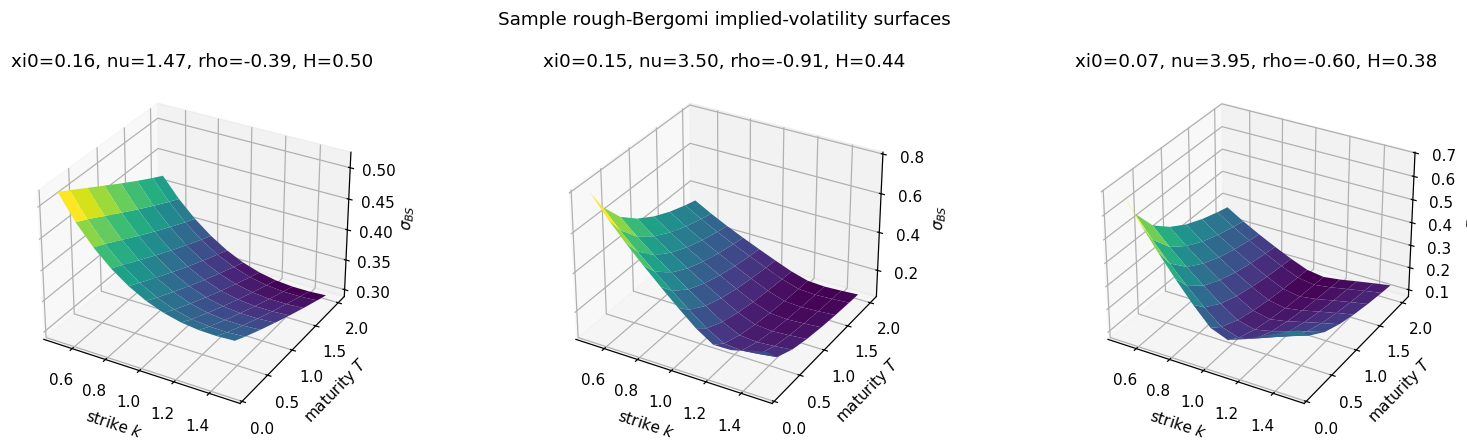

In [10]:
fig = plt.figure(figsize=(15, 4))
for n, j in enumerate(np.linspace(0, len(iv) - 1, 3).astype(int)):
    ax = fig.add_subplot(1, 3, n + 1, projection="3d")
    lab = ", ".join(f"{nm}={params[j, i]:.2f}" for i, nm in enumerate(PARAM_NAMES))
    plot_iv_surface(iv[j], ax=ax, title=lab)
fig.suptitle("Sample rough-Bergomi implied-volatility surfaces"); plt.tight_layout(); plt.show()

The panels below show the Monte Carlo error floor across the grid.

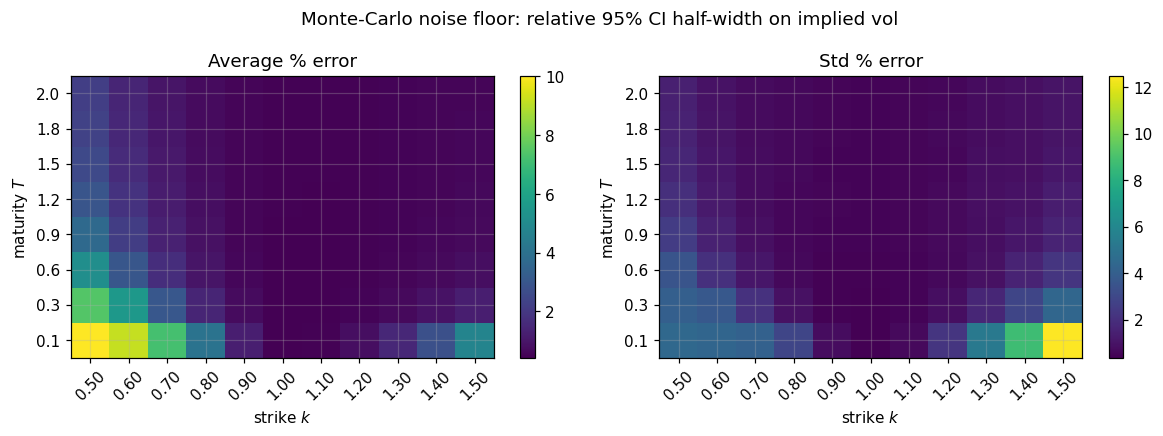

MC floor (relative CI half-width):  average 1.226%   median 0.573%   max 69.41%


In [11]:
def mc_relative_ci(iv_true, iv_se_, n_show=None):
    """Per-cell relative half-width of the 95% MC implied-vol CI (%).

    iv_se already encodes the honest 95% interval (the price-CI endpoints were inverted to
    vol space in section 1.2), so the relative half-width is simply 1.96*SE_sigma / sigma.
    NaN where that build-time inversion failed. n_show=None uses every surface.
    """
    if n_show is not None:
        iv_true, iv_se_ = iv_true[:n_show], iv_se_[:n_show]
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(iv_true > 0, 100.0 * 1.96 * iv_se_ / iv_true, np.nan)


mc_ci = mc_relative_ci(iv, iv_se)            # all surfaces (cf. paper: across the full set)
plot_error_panels(mc_ci, "Monte Carlo noise floor: relative 95% CI half-width on implied vol",
                  STRIKES, "strike $k$", save=f"{REPORT_DIR}/mc_floor.png")
print(f"MC floor (relative CI half-width):  average {np.nanmean(mc_ci):.3f}%   "
      f"median {np.nanmedian(mc_ci):.3f}%   max {np.nanmax(mc_ci):.2f}%")

Both panels indicate higher error floor and larger error variance in the wings (short maturity, deep-ITM and deep-OTM), where the option carries little time value. In these regions vega is small,
so Monte Carlo *price* noise is amplified in implied-vol units ($\mathrm{SE}_\sigma\approx
\mathrm{SE}_{\text{price}}/\text{vega}$).

- **Average** is largest for deep in-the-money, short-dated cells (low strike, short maturity): the
  price is almost entirely intrinsic and barely depends on volatility, so *every* surface inverts
  noisily there.
- **Std** is largest in the deep out-of-the-money wing (high strike): there the price is near zero
  and exponentially sensitive to the volatility of the underlying asset, so the floor swings from negligible to
  large across different model parameters.

## 2. Approximation network: training

We now learn $\widetilde F:\theta\mapsto$ implied-vol surface. This is the offline "Learn" stage:
once trained, the network approximates the pricing map, and it can be evaluated in microseconds for a given parameter vector, which makes the calibration step fast.

### 2.1 Empirical risk minimisation

Training is empirical risk minimisation. The hypothesis is the neural network $h(\cdot;w)=\widetilde F$;
the loss is squared error $\ell=\lVert h(\theta)-\sigma\rVert_2^2$. Since we cannot evaluate the true
risk $R(h)=\mathbb E[\ell]$, we minimise the **empirical risk** over the training set,

$$\widehat R_n(h)=\frac1n\sum_{j=1}^n\big\lVert \widetilde F(\theta^{(j)})-\sigma^{(j)}\big\rVert_2^2,$$

and monitor the held-out **test risk** as an unbiased estimate of $R(h)$. *Early stopping*, which
halts when the test risk stops improving, acts as the regulariser.

We map the parameters to $[-1,1]$ and standardise the surfaces to zero mean and unit variance,
then split 85% / 15% into training and test sets; the parameters are the features and the surfaces
the labels.

In [12]:
def scale_params(theta):
    """Map raw parameters to [-1, 1] (paper §3.2.2); works on a single vector or a stack of rows."""
    return (2.0 * np.asarray(theta) - (UB + LB)) / (UB - LB)

def unscale_params(z):
    """Inverse of scale_params: [-1, 1] -> raw parameter units."""
    return 0.5 * (np.asarray(z) * (UB - LB) + (UB + LB))

# Train/test split: features = parameters (theta), labels = IV surfaces.  85% / 15%.
assert not np.isnan(iv).any(), "drop NaN IV rows before training"
theta_train, theta_test, surf_train, surf_test = train_test_split(
    params, iv, test_size=0.15, random_state=rng_seed)

# Inputs scaled to [-1, 1]; surfaces standardised (subtract mean, divide by std) via StandardScaler.
surf_scaler = StandardScaler().fit(surf_train)
X_train, X_test = scale_params(theta_train), scale_params(theta_test)
Y_train, Y_test = surf_scaler.transform(surf_train), surf_scaler.transform(surf_test)
print(f"train {X_train.shape[0]}  test {X_test.shape[0]}   inputs {X_train.shape[1]}  outputs {Y_train.shape[1]}")

train 52343  test 9237   inputs 4  outputs 88


### 2.2 Network architecture

The paper's architecture is deliberately small: a fully-connected network with
**4 hidden layers of 30 ELU units** and a **linear** output of width 88. Two design choices are worth noting:

- **ELU activation** ($\sigma(x)=x$ for $x\ge0$, $\alpha(e^{x}-1)$ otherwise) is $C^1$. Theorem 2
  of the paper guarantees a network can approximate a function *and its derivatives* only with a
  smooth activation, and we need an accurate Jacobian $\partial\widetilde F/\partial\theta$ for
  calibration. ReLU is ruled out because it is non-differentiable at 0.
- **Depth 4** is motivated by the "power of depth" theorem and we observe that adding layers
  beyond four brings no real gain.

`build_forward_map` builds and compiles this network with an MSE loss and the Adam optimiser.

In [13]:
def build_forward_map(n_in=4, n_out=GRID_SIZE, n_hidden=4, width=30):
    inputs = keras.Input(shape=(n_in,))
    x = inputs
    for _ in range(n_hidden):
        x = keras.layers.Dense(width, activation="elu")(x)
    outputs = keras.layers.Dense(n_out, activation="linear")(x)
    model = keras.Model(inputs, outputs)
    model.compile(loss="mse", optimizer="adam")
    return model


keras.utils.set_random_seed(rng_seed)
model_iv = build_forward_map()
model_iv.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 88)             │         2,728 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,668 (44.28 KB)

 Trainable params: 5,668 (44.28 KB)

 Non-trainable params: 0 (0.00 B)

**Training.**
Keras's `fit` function handles all the training details including:
- mini-batching with a batch size of 32
- 200 epochs looping over the training data
- early stopping with a patience of 25: training stops if the test risk does not improve for 25 epochs.
- the weights from the best test-risk epoch are kept.

Trained weights and the loss history are cached (see `TRAIN` in Section 1.3): when `TRAIN` is False
and a cache exists, we reload it and skip fitting, so the downstream figures and calibration rerun
in seconds.

In [ ]:
from types import SimpleNamespace


def load_history(path):
    """Reload a cached fit history as an object exposing `.history` like a Keras History."""
    h = np.load(path)
    return SimpleNamespace(history={"loss": h["loss"].tolist(), "val_loss": h["val_loss"].tolist()})


if TRAIN or not os.path.exists(IV_WEIGHTS_PATH):
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=25, restore_best_weights=True)
    history = model_iv.fit(
        X_train, Y_train, validation_data=(X_test, Y_test),
        epochs=200, batch_size=32, callbacks=[early_stop], verbose=2)
    model_iv.save_weights(IV_WEIGHTS_PATH)
    np.savez(IV_HISTORY_PATH, loss=history.history["loss"], val_loss=history.history["val_loss"])
else:
    model_iv.load_weights(IV_WEIGHTS_PATH)
    history = load_history(IV_HISTORY_PATH)
    print(f"loaded cached IV weights from {IV_WEIGHTS_PATH} ({len(history.history['loss'])} epochs)")

Epoch 1/200
1636/1636 - 2s - 1ms/step - loss: 0.0458 - val_loss: 0.0051
Epoch 2/200
1636/1636 - 1s - 753us/step - loss: 0.0035 - val_loss: 0.0029
Epoch 3/200
1636/1636 - 1s - 734us/step - loss: 0.0023 - val_loss: 0.0019
Epoch 4/200
1636/1636 - 1s - 749us/step - loss: 0.0018 - val_loss: 0.0016
Epoch 5/200
1636/1636 - 1s - 753us/step - loss: 0.0016 - val_loss: 0.0016
Epoch 6/200
1636/1636 - 1s - 736us/step - loss: 0.0014 - val_loss: 0.0014
Epoch 7/200
1636/1636 - 1s - 733us/step - loss: 0.0013 - val_loss: 0.0013
Epoch 8/200
1636/1636 - 1s - 740us/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/200
1636/1636 - 1s - 793us/step - loss: 0.0012 - val_loss: 0.0013
Epoch 10/200
1636/1636 - 1s - 738us/step - loss: 0.0011 - val_loss: 0.0011
Epoch 11/200
1636/1636 - 1s - 785us/step - loss: 0.0011 - val_loss: 0.0012
Epoch 12/200
1636/1636 - 1s - 804us/step - loss: 0.0011 - val_loss: 0.0010
Epoch 13/200
1636/1636 - 1s - 876us/step - loss: 0.0011 - val_loss: 0.0011
Epoch 14/200
1636/1636 - 1s - 825us/

Training and test risk against epoch (log scale) below.
A small gap between the curves indicates good generalization rather than overfitting.

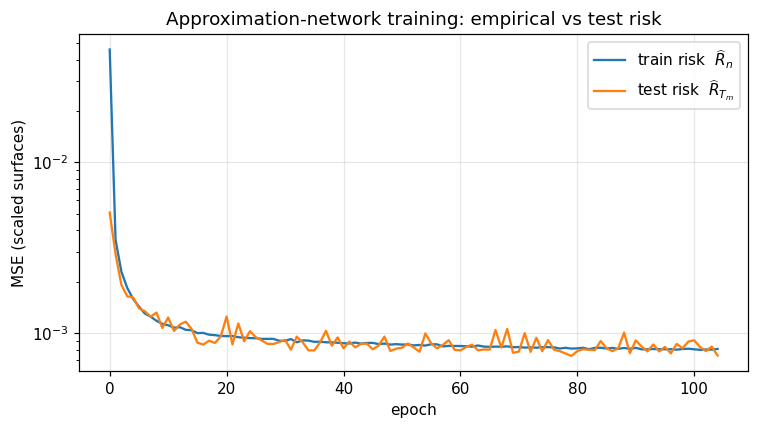

best epoch 79:  train 8.14e-04   test 7.38e-04


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label=r"train risk  $\widehat R_n$")
plt.plot(history.history["val_loss"], label=r"test risk  $\widehat R_{T_m}$")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE (scaled surfaces)")
plt.title("Approximation-network training: empirical vs test risk"); plt.legend(); plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/emp_risk_vstest.png", dpi=200, bbox_inches="tight")
plt.show()
best = int(np.argmin(history.history["val_loss"]))
print(f"best epoch {best}:  train {history.history['loss'][best]:.2e}   test {history.history['val_loss'][best]:.2e}")

**Accuracy versus Monte Carlo.** We compare the network to the MC label on the test set
as a relative error:
$100\cdot|\sigma_{\mathrm{NN}}-\sigma_{\mathrm{MC}}|/\sigma_{\mathrm{MC}}$.

The mean relative error is around $0.43\%$. This is small in practical terms, below a typical bid-ask
spread (about $1\%$ in relative implied-volatility terms for liquid options), so the network is accurate
enough to calibrate against market data. It is also of the same order as the Monte Carlo sampling floor
of §1.4, so the network is about as accurate as the data it was trained on.

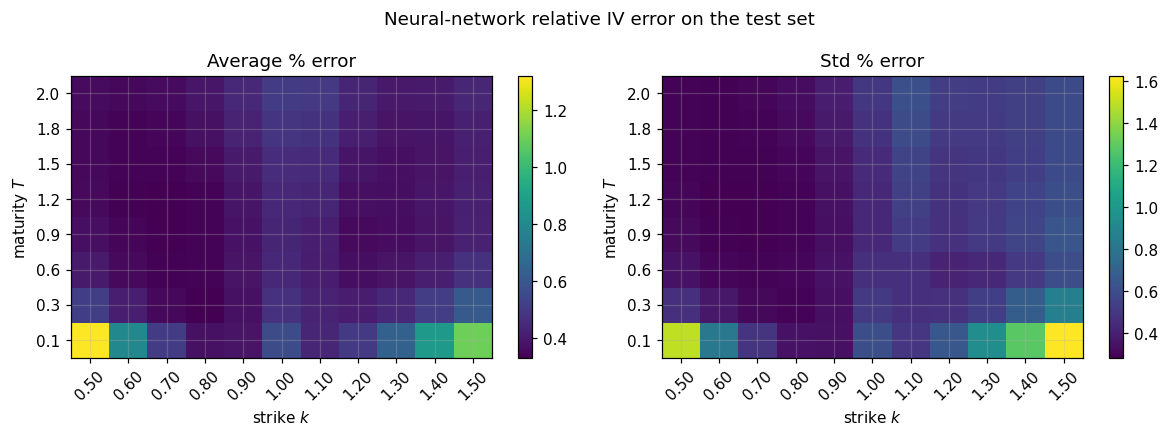

NN test error:  average 0.434%   std 0.556%   max 33.36%   (cf. MC floor average 1.226%)


In [ ]:
pred_test = surf_scaler.inverse_transform(model_iv.predict(X_test, verbose=0))
nn_rel = 100.0 * np.abs(surf_test - pred_test) / surf_test
plot_error_panels(nn_rel, "Neural-network relative IV error on the test set", STRIKES, "strike $k$",
                  save=f"{REPORT_DIR}/NN_error.png")
print(f"NN test error:  average {nn_rel.mean():.3f}%   std {nn_rel.std():.3f}%   "
      f"max {nn_rel.max():.2f}%   (cf. MC floor average {np.nanmean(mc_ci):.3f}%)")

The approximation read as implied-vol smiles:
- each curve is one maturity slice (colour = maturity),
- solid is the Monte Carlo price and dashed is the network's approximation

We show the **best**- and **worst**-approximated test surfaces, ranked by mean percentage error, so the panels bracket the network's accuracy. The dashed curves track the solid ones closely even in the worst case.

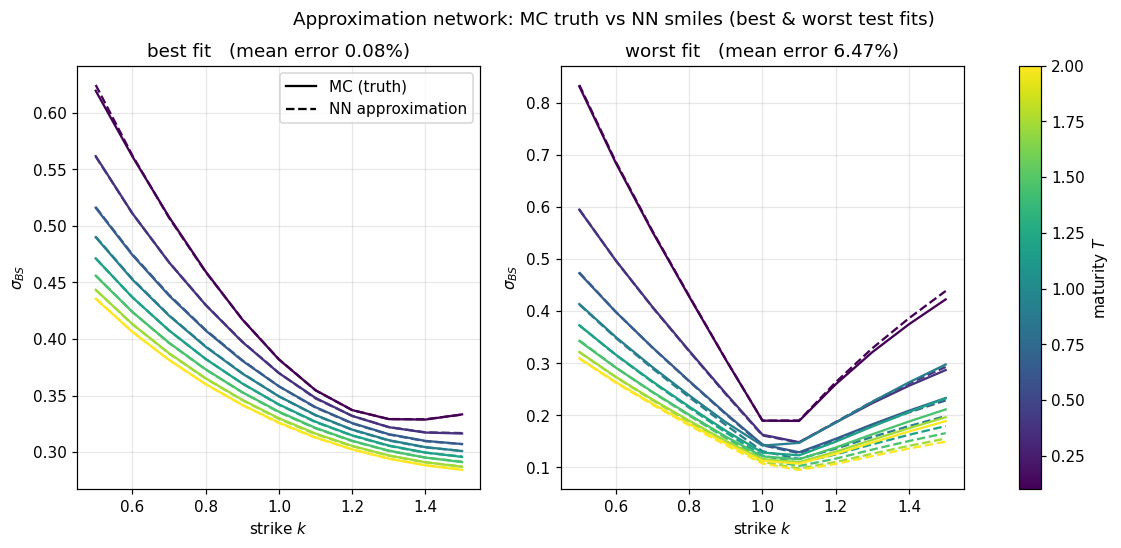

In [ ]:
nn_mape = nn_rel.mean(axis=1)
nn_best, nn_worst = int(np.argmin(nn_mape)), int(np.argmax(nn_mape))
plot_smile_comparison(
    [(surf_test[nn_best],  pred_test[nn_best],  f"best fit   (mean error {nn_mape[nn_best]:.2f}%)"),
     (surf_test[nn_worst], pred_test[nn_worst], f"worst fit   (mean error {nn_mape[nn_worst]:.2f}%)")],
    "MC (truth)", "NN approximation",
    "Approximation network: MC truth vs NN smiles (best & worst test fits)",
    save=f"{REPORT_DIR}/smiles.png")

### 2.3 Extension: a digital-barrier surface

The image-based approach is not specific to vanillas (paper §4.3). We train a *second* network,
with the same architecture, to map $\theta$ to the **down-and-out digital** surface on the
maturity × barrier grid (the down-and-in follows from $\mathrm{DI}=1-\mathrm{DO}$). Here the
target is the price itself, a probability in $[0,1]$ rather than an implied volatility, so we
report errors in absolute **basis points** rather than as percentages.

In [ ]:
theta_tr_b, theta_te_b, do_tr, do_te = train_test_split(
    bar_params, do, test_size=0.15, random_state=rng_seed)
do_scaler = StandardScaler().fit(do_tr)
Xb_tr, Xb_te = scale_params(theta_tr_b), scale_params(theta_te_b)
Yb_tr, Yb_te = do_scaler.transform(do_tr), do_scaler.transform(do_te)

keras.utils.set_random_seed(rng_seed)
model_barrier = build_forward_map(n_out=N_MAT * N_BARRIER)
if TRAIN or not os.path.exists(BARRIER_WEIGHTS_PATH):
    hist_b = model_barrier.fit(
        Xb_tr, Yb_tr, validation_data=(Xb_te, Yb_te),
        epochs=200, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)],
        verbose=0)
    model_barrier.save_weights(BARRIER_WEIGHTS_PATH)
    np.savez(BARRIER_HISTORY_PATH, loss=hist_b.history["loss"], val_loss=hist_b.history["val_loss"])
else:
    model_barrier.load_weights(BARRIER_WEIGHTS_PATH)
    hist_b = load_history(BARRIER_HISTORY_PATH)
    print(f"loaded cached barrier weights from {BARRIER_WEIGHTS_PATH}")
print(f"barrier model: best test MSE {min(hist_b.history['val_loss']):.2e} after {len(hist_b.history['loss'])} epochs")

barrier model: best test MSE 7.03e-04 after 91 epochs


Absolute down-and-out error on the test set, in basis points (paper Fig 13).

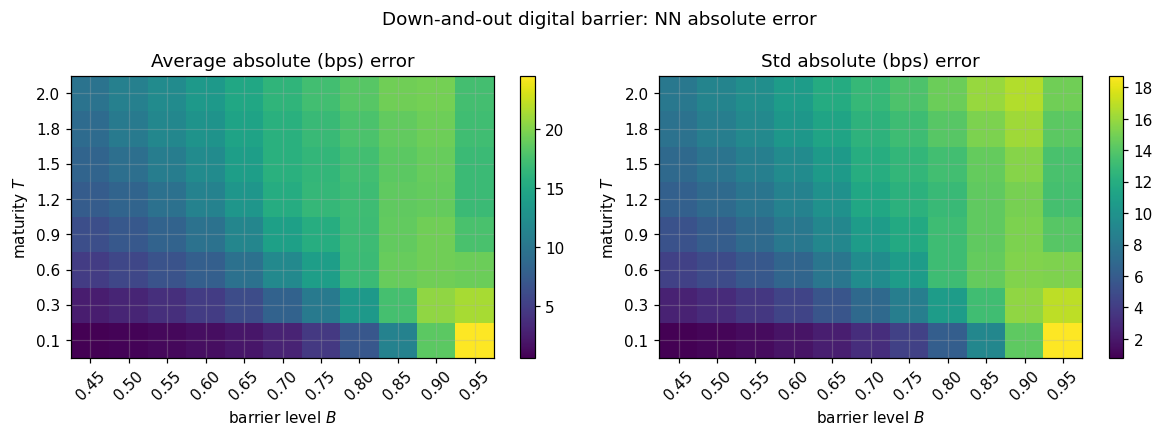

barrier abs error:  average 12.65 bps   max 176.7 bps


In [ ]:
pred_b = do_scaler.inverse_transform(model_barrier.predict(Xb_te, verbose=0))
bar_abs = np.abs(pred_b - do_te)        # absolute error in price units (DO price in [0, 1])
plot_error_panels(bar_abs, "Down-and-out digital barrier: NN absolute error",
                  BARRIERS, "barrier level $B$", scale=1e4, unit_label="absolute (bps)")
print(f"barrier abs error:  average {bar_abs.mean() * 1e4:.2f} bps   max {bar_abs.max() * 1e4:.1f} bps")

## 3. Calibration

The online stage. With the network frozen, calibration is a deterministic least-squares fit

$$\hat\theta=\arg\min_\theta\sum_{i,j}\big(\widetilde F(\theta)_{ij}-\sigma^{\mathrm{MKT}}_{ij}\big)^2,$$

solved by **Levenberg–Marquardt** (`scipy.optimize.least_squares`). Because the network is cheap
and differentiable, each fit takes milliseconds.

### 3.1 A NumPy copy of the network

The optimiser calls the network and its Jacobian many times per fit. Rather than pay framework
overhead in that inner loop, we copy the trained weights into a few NumPy arrays and re-implement
the forward pass and its **analytic** Jacobian by hand. The exact gradient, rather than finite
differences, is precisely what the $C^1$ ELU activation makes possible.

Keras stores a `Dense` layer's kernel as **(inputs, outputs)**, so the forward pass is simply
`a @ W + b`, with no transpose needed. The cell checks this copy reproduces the Keras model to
machine precision.

In [ ]:
NUM_HIDDEN = 4
dense_layers = [L for L in model_iv.layers if isinstance(L, keras.layers.Dense)]
nn_params = [tuple(L.get_weights()) for L in dense_layers]   # (kernel (in, out), bias (out,)) per layer
assert len(nn_params) == NUM_HIDDEN + 1

def elu(x):        return np.where(x < 0, np.exp(x) - 1.0, x)
def elu_prime(x):  return np.where(x < 0, np.exp(x), 1.0)

def neural_network(z):
    """Forward pass: scaled params (4,) -> scaled surface (88,)."""
    a = np.asarray(z, dtype=float)
    for W, b in nn_params[:NUM_HIDDEN]:
        a = elu(a @ W + b)
    W, b = nn_params[NUM_HIDDEN]
    return a @ W + b

def neural_network_gradient(z):
    """Analytic Jacobian d(output)/d(input), shape (4, 88), via the chain rule."""
    a = np.asarray(z, dtype=float)
    grad = np.eye(4)
    for W, b in nn_params[:NUM_HIDDEN]:
        a = a @ W + b
        grad = (grad @ W) * elu_prime(a)        # broadcast (4, width) * (width,)
        a = elu(a)
    W, b = nn_params[NUM_HIDDEN]
    return grad @ W

# Check the NumPy mirror reproduces the Keras model (scaled space).
z0 = scale_params(theta_test[0])
print("max |numpy - keras| =", np.abs(neural_network(z0) - model_iv.predict(z0[None], verbose=0)[0]).max())

max |numpy - keras| = 8.881784197001252e-16


### 3.2 Calibrating with Levenberg–Marquardt

We calibrate each test surface in turn, starting from the centre of the (scaled) parameter box.
The residual and Jacobian are supplied in scaled coordinates, and the recovered parameters are
mapped back to raw units afterwards. We run this over up to 1000 test surfaces and report the
average time per calibration.

In [ ]:
def residuals(z, target_scaled):
    return neural_network(z) - target_scaled

def jacobian(z, target_scaled):
    return neural_network_gradient(z).T          # (88, 4) as least_squares expects

# Calibrate every test surface and time it.
n_calib = min(1000, len(X_test))
z_init = np.zeros(4)
calibrated, timings = [], []
for i in range(n_calib):
    t0 = time.perf_counter()
    sol = least_squares(residuals, z_init, jac=jacobian, args=(Y_test[i],), method="lm")
    timings.append(time.perf_counter() - t0)
    calibrated.append(unscale_params(sol.x))
calibrated = np.array(calibrated)
print(f"calibrated {n_calib} surfaces;  average time = {1e3 * np.mean(timings):.2f} ms per surface")

calibrated 1000 surfaces;  average time = 0.57 ms per surface


Calibration quality: the relative error per parameter, and the RMSE between the target surface and
the surface at the recovered parameters.

In [ ]:
true_theta = theta_test[:n_calib]
param_rel_err = np.abs(calibrated - true_theta) / np.abs(true_theta)

recon = surf_scaler.inverse_transform(
    np.array([neural_network(scale_params(p)) for p in calibrated]))
rmse = np.sqrt(np.mean((recon - surf_test[:n_calib]) ** 2, axis=1))

print("median parameter relative error (%):")
for nm, e in zip(PARAM_NAMES, np.median(param_rel_err, axis=0) * 100):
    print(f"   {nm:>4}: {e:6.2f}")
print(f"median surface RMSE = {np.median(rmse) * 100:.3f}%   (99% quantile {np.quantile(rmse, 0.99) * 100:.3f}%)")

median parameter relative error (%):
    xi0:   0.59
     nu:   0.65
    rho:   0.91
      H:   1.76
median surface RMSE = 0.095%   (99% quantile 0.438%)


Empirical CDFs of the parameter relative errors and of the surface RMSE (paper Figs 9–10); the
paper's benchmark is a 99% RMSE quantile below 1%.

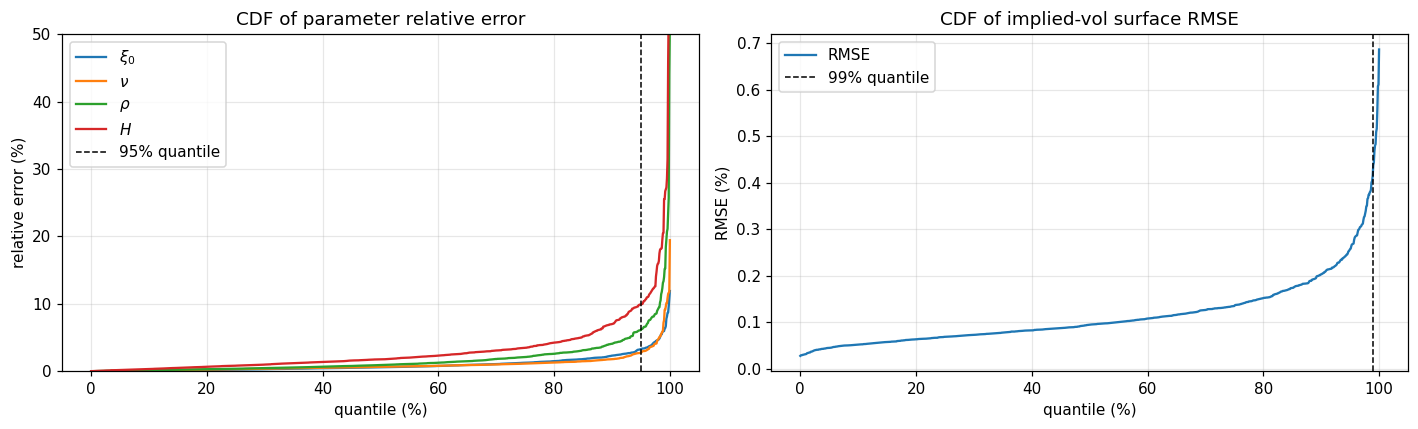

In [ ]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
q = np.linspace(0, 1, n_calib)
for i, nm in enumerate(PARAM_TEX):
    axL.plot(q * 100, np.sort(param_rel_err[:, i]) * 100, label=nm)
axL.axvline(95, ls="--", c="k", lw=1, label="95% quantile")
axL.set_ylim(0, 50); axL.set_xlabel("quantile (%)"); axL.set_ylabel("relative error (%)")
axL.set_title("CDF of parameter relative error"); axL.legend()

axR.plot(q * 100, np.sort(rmse) * 100, label="RMSE")
axR.axvline(99, ls="--", c="k", lw=1, label="99% quantile")
axR.set_xlabel("quantile (%)"); axR.set_ylabel("RMSE (%)")
axR.set_title("CDF of implied-vol surface RMSE"); axR.legend()
plt.tight_layout()
fig.savefig(f"{REPORT_DIR}/calib_cdf.png", dpi=200, bbox_inches="tight")
plt.show()

The CDFs above aggregate the parameter error over all surfaces. We now look at how the recovered
relative error $100\,|\hat\theta-\theta|/|\theta|$ varies with the true parameter value, one panel
per parameter.

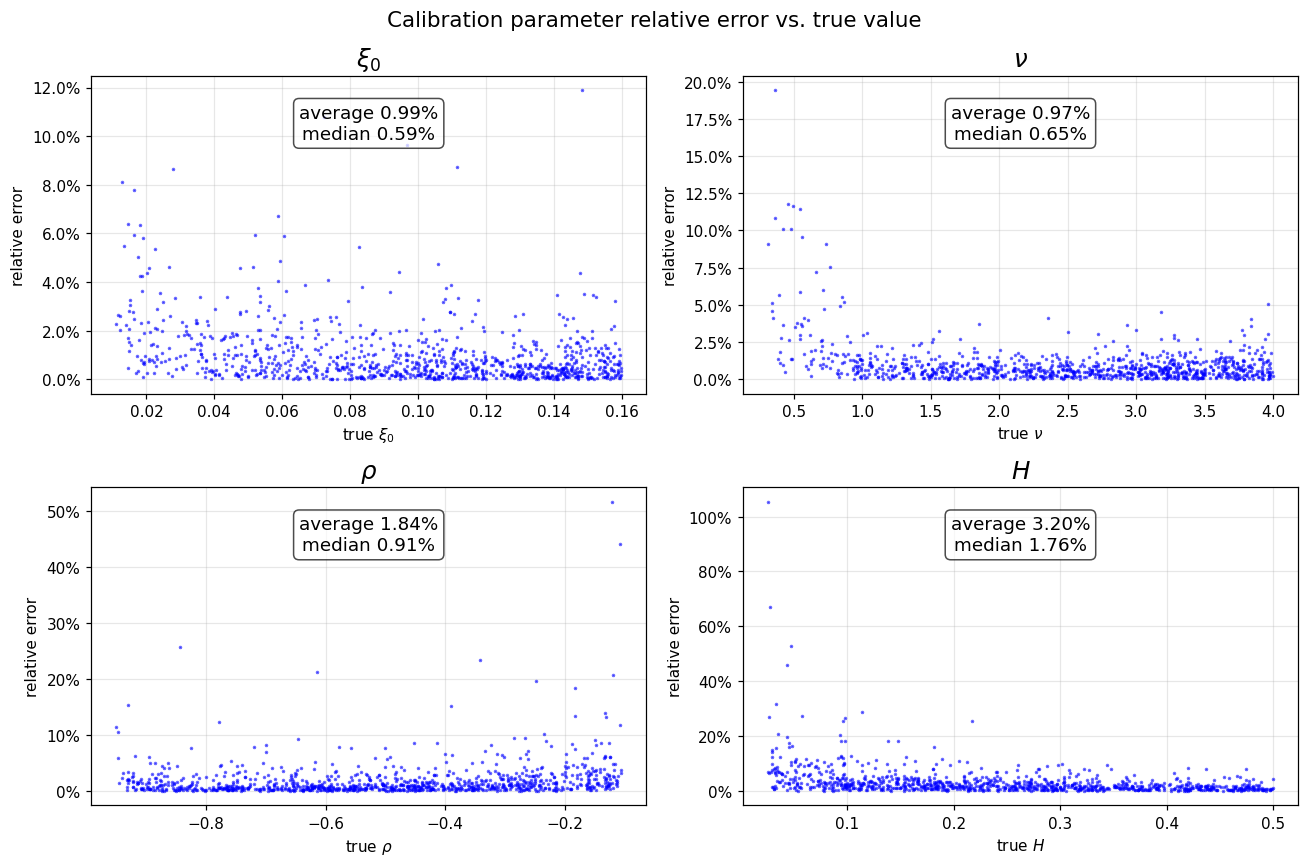

In [ ]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for u, ax in enumerate(axes.flat):
    x = true_theta[:, u]
    y = 100.0 * param_rel_err[:, u]
    ax.plot(x, y, "b*", markersize=2, alpha=0.5)
    ax.set_title(PARAM_TEX[u], fontsize=16)
    ax.set_xlabel(f"true {PARAM_TEX[u]}"); ax.set_ylabel("relative error")
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.text(0.5, 0.85, f"average {y.mean():.2f}%\nmedian {np.median(y):.2f}%",
            ha="center", va="center", transform=ax.transAxes, fontsize=12,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))
fig.suptitle("Calibration parameter relative error vs. true value", fontsize=14)
plt.tight_layout()
fig.savefig(f"{REPORT_DIR}/calib_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

We read calibration quality as implied-vol smiles: each curve is one maturity slice (implied vol
against strike, coloured by maturity), with the market target solid and the surface at the
recovered parameters dashed. The panels show the **best**- and **worst**-fit test surfaces, ranked
by **mean percentage error** $\frac1{88}\sum_i|\sigma^{\mathrm{fit}}_i-\sigma^{\mathrm{MKT}}_i|/
\sigma^{\mathrm{MKT}}_i$ rather than RMSE, which scales with the overall vol level and would merely
select the lowest- and highest-vol smiles. The two panels thus bracket the *relative* calibration
error.

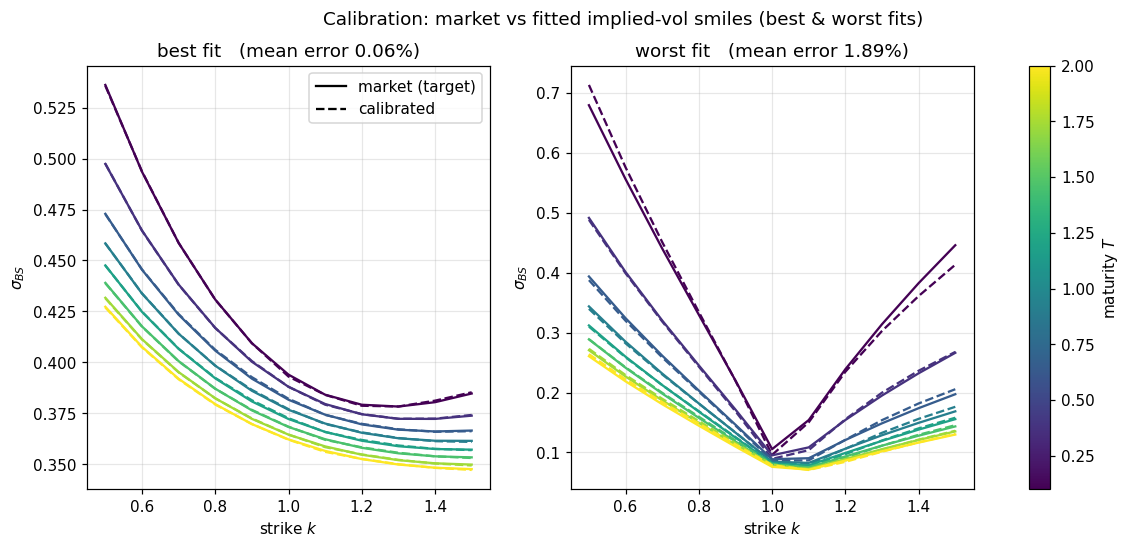

In [ ]:
mape = 100.0 * np.mean(np.abs(recon - surf_test[:n_calib]) / surf_test[:n_calib], axis=1)
best, worst = int(np.argmin(mape)), int(np.argmax(mape))
plot_smile_comparison(
    [(surf_test[best],  recon[best],  f"best fit   (mean error {mape[best]:.2f}%)"),
     (surf_test[worst], recon[worst], f"worst fit   (mean error {mape[worst]:.2f}%)")],
    "market (target)", "calibrated",
    "Calibration: market vs fitted implied-vol smiles (best & worst fits)",
    save=f"{REPORT_DIR}/calib_smiles.png")

### 3.3 Choosing the optimiser

Section 3.2 used Levenberg–Marquardt, but it is only one of many optimisers able to solve the
frozen-network calibration. Following the paper (§3.3 and Fig. 8) we compare seven, in two families:

- **Gradient-based** — Levenberg–Marquardt, BFGS, L-BFGS-B, SLSQP. These exploit the exact analytic
  Jacobian of §3.1 and converge in very few iterations, but rely on the smoothness the $C^1$ ELU
  activation provides.
- **Gradient-free** — Nelder–Mead, COBYLA, Differential Evolution. These need no derivatives and can
  escape local minima (Differential Evolution is a global search), at the cost of many more function
  evaluations.

We calibrate the same batch of test surfaces with each optimiser, timing every fit and recording the
surface RMSE it attains. As in the paper, Levenberg–Marquardt gives the best speed/accuracy balance,
which is why §3.2 adopts it.

In [ ]:
from scipy.optimize import minimize, differential_evolution

def cost_scalar(z, target_scaled):
    """Sum-of-squares objective for the scalar minimisers."""
    r = neural_network(z) - target_scaled
    return float(r @ r)

def cost_grad(z, target_scaled):
    """Analytic gradient of cost_scalar, d/dz of ||NN(z) - target||^2, shape (4,)."""
    r = neural_network(z) - target_scaled
    return 2.0 * (neural_network_gradient(z) @ r)

SCALED_BOX = [(-1.0, 1.0)] * 4              # parameter box in scaled coordinates
GRAD_BASED = {"Levenberg-Marquardt", "BFGS", "L-BFGS-B", "SLSQP"}

def calibrate_with(method, target):
    """Calibrate one surface and return the recovered scaled parameters, using `method`."""
    z0 = np.zeros(4)
    if method == "Levenberg-Marquardt":                       # least-squares: residual + Jacobian
        return least_squares(residuals, z0, jac=jacobian, args=(target,), method="lm").x
    if method == "Differential Evolution":                    # gradient-free global search
        return differential_evolution(cost_scalar, SCALED_BOX, args=(target,),
                                      tol=1e-7, maxiter=100, seed=0, polish=True).x
    kw = {"args": (target,)}
    if method in {"BFGS", "L-BFGS-B", "SLSQP"}:
        kw["jac"] = cost_grad                                 # supply the analytic gradient
    if method in {"L-BFGS-B", "SLSQP"}:
        kw["bounds"] = SCALED_BOX                             # box-constrained variants
    return minimize(cost_scalar, z0, method=method, **kw).x

OPTIMIZERS = ["L-BFGS-B", "SLSQP", "BFGS", "Levenberg-Marquardt",
              "COBYLA", "Differential Evolution", "Nelder-Mead"]

n_opt = min(50, len(X_test))               # surfaces used for the optimiser comparison
opt_time, opt_rmse = {}, {}
for m in OPTIMIZERS:
    ts, recon_m = [], []
    for i in range(n_opt):
        t0 = time.perf_counter()
        z_hat = calibrate_with(m, Y_test[i])
        ts.append(time.perf_counter() - t0)
        recon_m.append(neural_network(z_hat))
    recon_m = surf_scaler.inverse_transform(np.array(recon_m))
    opt_rmse[m] = float(np.median(np.sqrt(np.mean((recon_m - surf_test[:n_opt]) ** 2, axis=1))))
    opt_time[m] = 1e3 * np.mean(ts)
    print(f"{m:>22}:  {opt_time[m]:8.2f} ms/surface   median RMSE {opt_rmse[m] * 100:.3f}%")

Average calibration time per optimiser on a log scale — the analogue of the paper's Fig. 8.
Gradient-based methods are one to three orders of magnitude faster than the gradient-free ones, and
Levenberg–Marquardt is the fastest while still reaching the same surface RMSE (printed above), so we
keep it as the default of §3.2.

In [ ]:
order = sorted(OPTIMIZERS, key=lambda m: opt_time[m])
bar_colors = ["#1f77b4" if m in GRAD_BASED else "#ff7f0e" for m in order]
plt.figure(figsize=(9, 4.5))
plt.bar(range(len(order)), [opt_time[m] for m in order], color=bar_colors)
plt.yscale("log"); plt.ylabel("milliseconds per surface (log scale)")
plt.xticks(range(len(order)), order, rotation=30, ha="right")
plt.title("Average calibration time with different optimisers")
plt.legend(handles=[Line2D([0], [0], color="#1f77b4", lw=6, label="gradient-based"),
                    Line2D([0], [0], color="#ff7f0e", lw=6, label="gradient-free")], loc="upper left")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/calib_optimizers.png", dpi=200, bbox_inches="tight")
plt.show()

## Conclusion

- A small $4\times 30$ ELU network reproduces the rough Bergomi pricing map to within the
  Monte Carlo error floor (Section 2 vs §1.2).
- Levenberg–Marquardt calibration over the frozen network runs in milliseconds per surface, a
  $\sim\!10^4\times$ speed-up over brute-force Monte Carlo (paper Table 2), at low surface RMSE.
- Comparing seven optimisers (§3.3) confirms the paper's finding: gradient-based methods, which use
  the analytic Jacobian, are orders of magnitude faster than gradient-free ones, with
  Levenberg–Marquardt the best speed/accuracy trade-off.
- The same architecture transfers unchanged to a digital-barrier surface (§2.3), with an
  average error of about 10–15 basis points.


**Scope and extensions.** We treated the rough Bergomi model with a *flat* forward-variance level.
The natural next steps, following the paper, are a **piecewise-constant forward-variance curve**
$\xi_0(t)$ (eight extra inputs, enabling a realistic term structure) and **calibration to
historical SPX** implied-vol surfaces.